# Battery Health — Model Training (scikit-learn baselines)

Trains and evaluates scikit-learn baseline models for two tasks:

| Task | Target | Notes |
|---|---|---|
| **Lifespan** | `rul_frac` — remaining useful life as a fraction | Comparable across datasets; MAE back-converted to cycles for readability |
| **Efficiency** | `energy_retention` — discharge energy / early-life baseline | V·\|I\| integration; captures both capacity loss and voltage sag from rising internal resistance |

Each task runs in two phases:

| Phase | Data | Resistance feature | Purpose |
|---|---|---|---|
| **1 — Oracle** | Controlled (B0005–B0018) | EIS `Re`/`Rct` + proxy `r_proxy` | Lab upper bound |
| **2 — Practical** | Controlled + Randomized merged | `r_proxy` only | Field-realistic; simulates renewable-energy deployment |

Three algorithms per (phase, task): **Ridge Regression → Random Forest → Gradient Boosting**, all
hyperparameter-tuned with **Optuna** (LOBO-CV as objective).

Metrics reported:
- **MAE / RMSE / R²** (mean ± std across LOBO folds)
- **MAE vs. naive baseline** (predict training-fold mean) — shows how much the model actually learns
- **Spearman ρ** — rank-order correlation; captures whether relative degradation severity is preserved
- **Monotonicity rate** — % of consecutive-cycle pairs in the held-out battery where the prediction decreases, matching the true monotone decline

> **Tiny-data caveat:** 4 (oracle) / 13 (practical) batteries → wide fold-to-fold variance. Treat numbers as order-of-magnitude estimates.

## 1. Imports & paths

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import optuna
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="darkgrid", palette="tab10")

PROCESSED = Path("../data/processed")
RESULTS   = Path("../results")
MODELS    = Path("../models")
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

ctrl = pd.read_csv(PROCESSED / "controlled.csv")
rw   = pd.read_csv(PROCESSED / "randomized.csv")

print(f"Controlled: {len(ctrl)} rows, {ctrl.battery_id.nunique()} batteries: {sorted(ctrl.battery_id.unique())}")
print(f"Randomized: {len(rw)}  rows, {rw.battery_id.nunique()} batteries: {sorted(rw.battery_id.unique())}")

Controlled: 636 rows, 4 batteries: ['B0005', 'B0006', 'B0007', 'B0018']
Randomized: 165  rows, 9 batteries: ['RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']


## 2. Feature sets & leakage guards

**Columns that must never be features:**

| Column | Reason |
|---|---|
| `eol_index`, `rul_cycles`, `rul_frac`, `rul_censored` | RUL labels / label-derived |
| `energy_retention`, `energy_wh` | Efficiency labels / label-derived |
| `cycle_norm` | = `cycle_index / max_cycle` — encodes total lifespan → **look-ahead leak** |
| `battery_id`, `cycle_index`, `split` | IDs / bookkeeping |

**Efficiency feature restriction:** drop `capacity_ahr`, `cap_fade_rate`, `cap_delta_from_baseline`, `capacity_retention` — they track the same degradation signal as `energy_retention`. The remaining features (voltage, temperature, resistance, duration) are independent telemetry.

In [2]:
ID_COLS       = ["battery_id", "cycle_index", "split"]
LEAK_COLS     = ["eol_index", "rul_cycles", "rul_frac", "rul_censored", "cycle_norm",
                 "energy_retention", "energy_wh"]
CAPACITY_COLS = ["capacity_ahr", "capacity_retention", "cap_fade_rate", "cap_delta_from_baseline"]
EIS_COLS      = ["Re", "Rct"]
CTRL_ONLY     = ["voltage_min", "avg_current_a"] + EIS_COLS


def make_feature_set(df: pd.DataFrame, exclude_eis: bool = False,
                     exclude_capacity: bool = False) -> list[str]:
    drop = set(ID_COLS) | set(LEAK_COLS) | {"_baseline", "_energy_baseline",
                                             "temp_condition", "rw_condition",
                                             "cutoff_v", "ambient_temp", "timestamp"}
    if exclude_eis:
        drop |= set(EIS_COLS)
    if exclude_capacity:
        drop |= set(CAPACITY_COLS)
    return [c for c in df.columns if c not in drop and pd.api.types.is_numeric_dtype(df[c])]


oracle_lifespan_feat   = make_feature_set(ctrl, exclude_eis=False, exclude_capacity=False)
oracle_efficiency_feat = make_feature_set(ctrl, exclude_eis=False, exclude_capacity=True)

print("Oracle lifespan features:",   oracle_lifespan_feat)
print()
print("Oracle efficiency features:", oracle_efficiency_feat)

Oracle lifespan features: ['capacity_ahr', 'capacity_retention', 'voltage_min', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s', 'avg_current_a', 'r_proxy', 'Re', 'Rct', 'cap_delta_from_baseline']

Oracle efficiency features: ['voltage_min', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s', 'avg_current_a', 'r_proxy', 'Re', 'Rct']


## 3. LOBO-CV harness & metrics

**Metrics computed per fold:**

| Metric | Interpretation |
|---|---|
| **MAE** | Mean absolute error (same units as target, 0–1) |
| **RMSE** | Penalises large errors more heavily |
| **R²** | Fraction of variance explained; negative = worse than predicting the mean |
| **Naive MAE** | MAE of predicting the training-fold mean for every test point — the reference floor |
| **Skill score** | 1 − MAE / naive_MAE; 0 = no better than naive, 1 = perfect |
| **Spearman ρ** | Rank correlation; 1 = perfect ordering of degradation severity |
| **Monotonicity** | Fraction of consecutive-cycle pairs where ŷ[t+1] ≤ ŷ[t] within the held-out battery — true targets always decrease |
| **MAE (cycles)** | Lifespan only — MAE back-converted to absolute remaining cycles |

In [3]:
def monotonicity_rate(y_pred: np.ndarray) -> float:
    """Fraction of consecutive pairs where prediction decreases (matches true monotone decline)."""
    if len(y_pred) < 2:
        return float("nan")
    diffs = np.diff(y_pred)
    return float((diffs <= 0).mean())


def lobo_cv(df: pd.DataFrame, feature_cols: list[str], target: str,
            model_factory, eol_col: str = None) -> dict:
    X      = df[feature_cols].to_numpy()
    y      = df[target].to_numpy()
    groups = df["battery_id"].to_numpy()
    logo   = LeaveOneGroupOut()
    fold_results = []

    for train_idx, test_idx in logo.split(X, y, groups):
        held_out   = groups[test_idx][0]
        model      = model_factory()
        model.fit(X[train_idx], y[train_idx])
        y_pred     = model.predict(X[test_idx])
        naive_pred = np.full(len(test_idx), y[train_idx].mean())
        naive_mae  = mean_absolute_error(y[test_idx], naive_pred)
        mae        = mean_absolute_error(y[test_idx], y_pred)

        # Sort by cycle index within the held-out battery for monotonicity
        order      = np.argsort(df.iloc[test_idx]["cycle_index"].values)
        y_pred_ord = y_pred[order]

        fold = {
            "battery":     held_out,
            "n_test":      len(test_idx),
            "mae":         mae,
            "rmse":        float(np.sqrt(mean_squared_error(y[test_idx], y_pred))),
            "r2":          r2_score(y[test_idx], y_pred),
            "naive_mae":   naive_mae,
            "skill":       float(1 - mae / naive_mae) if naive_mae > 0 else float("nan"),
            "spearman":    float(spearmanr(y[test_idx], y_pred).statistic),
            "monotonicity": monotonicity_rate(y_pred_ord),
        }
        if eol_col is not None:
            eol = df.iloc[test_idx][eol_col].to_numpy()
            fold["mae_cycles"] = mean_absolute_error(y[test_idx] * eol, y_pred * eol)

        fold_results.append(fold)

    summary = {}
    for key in ["mae", "rmse", "r2", "naive_mae", "skill", "spearman", "monotonicity", "mae_cycles"]:
        vals = [f[key] for f in fold_results if key in f and not np.isnan(f[key])]
        if vals:
            summary[key]           = float(np.mean(vals))
            summary[f"{key}_std"]  = float(np.std(vals))

    summary["per_fold"] = fold_results
    return summary


def run_phase(df, feature_cols, target, phase_label, task_label,
              tuned_factories: dict, eol_col=None):
    rows = []
    for algo_name, factory in tuned_factories.items():
        res = lobo_cv(df, feature_cols, target, factory, eol_col=eol_col)
        row = {"Phase": phase_label, "Task": task_label, "Algorithm": algo_name,
               **{k: res[k] for k in ["mae", "mae_std", "rmse", "rmse_std",
                                      "r2", "r2_std", "naive_mae", "skill",
                                      "spearman", "monotonicity"] if k in res}}
        if "mae_cycles" in res:
            row["mae_cycles"]     = res["mae_cycles"]
            row["mae_cycles_std"] = res.get("mae_cycles_std", float("nan"))
        rows.append(row)

        skill_str = f"  skill={res.get('skill', float('nan')):.3f}" if "skill" in res else ""
        cyc_str   = f"  MAE_cyc={res['mae_cycles']:.1f}" if "mae_cycles" in res else ""
        print(f"  {algo_name:7s}  MAE={res['mae']:.4f}±{res['mae_std']:.4f}  "
              f"R²={res['r2']:.3f}±{res['r2_std']:.3f}  "
              f"ρ={res.get('spearman', float('nan')):.3f}  "
              f"mono={res.get('monotonicity', float('nan')):.3f}"
              f"{skill_str}{cyc_str}")

    return pd.DataFrame(rows)


print("Harness ready.")

Harness ready.


## 4. Hyperparameter tuning with Optuna

Objective: minimise mean LOBO-CV MAE. Fits are near-instantaneous with these dataset sizes, so
we can afford 100 trials per (phase × task × algorithm) combination.

Ridge replaces plain linear regression — its regularisation strength `alpha` is also tuned.

In [11]:
N_TRIALS   = {"Ridge": 30, "RF": 200, "GBM": 400}
N_STARTUP  = {"Ridge": 10, "RF": 25,  "GBM": 50}

def optuna_tune(df: pd.DataFrame, feature_cols: list[str], target: str,
                algo: str) -> dict:
    """
    Tune hyperparameters for `algo` ∈ {"Ridge", "RF", "GBM"} using LOBO-CV MAE as objective.
    Returns the best hyperparameter dict.
    """
    X      = df[feature_cols].to_numpy()
    y      = df[target].to_numpy()
    groups = df["battery_id"].to_numpy()
    logo   = LeaveOneGroupOut()

    def objective(trial):
        if algo == "Ridge":
            params = {"alpha": trial.suggest_float("alpha", 1e-4, 1e2, log=True)}
            model  = Pipeline([("scaler", StandardScaler()),
                                ("ridge", Ridge(**params))])
        elif algo == "RF":
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 50, 500),
                "max_depth":        trial.suggest_int("max_depth", 3, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
                "max_features":     trial.suggest_float("max_features", 0.3, 1.0),
                "random_state":     42,
            }
            model = RandomForestRegressor(**params)
        elif algo == "GBM":
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 50, 500),
                "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
                "random_state":     42,
                "verbosity":        0,
            }
            model = XGBRegressor(**params)

        maes = []
        for train_idx, test_idx in logo.split(X, y, groups):
            model.fit(X[train_idx], y[train_idx])
            maes.append(mean_absolute_error(y[test_idx], model.predict(X[test_idx])))
        return float(np.mean(maes))

    sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=N_STARTUP[algo])
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS[algo], show_progress_bar=True)
    return study.best_params


def make_factory(algo: str, params: dict):
    """Return a zero-arg factory that builds a model with the given params."""
    if algo == "Ridge":
        return lambda: Pipeline([("scaler", StandardScaler()),
                                  ("ridge", Ridge(alpha=params["alpha"]))])
    if algo == "RF":
        p = {**params, "random_state": 42}
        return lambda: RandomForestRegressor(**p)
    if algo == "GBM":
        p = {**params, "random_state": 42, "verbosity": 0}
        return lambda: XGBRegressor(**p)


print("Optuna tuning helper ready.")


Optuna tuning helper ready.


### 4a. GBM learning curves

XGBoost records train and validation MAE at every boosting round via `eval_set`.
This reveals whether the tuned number of trees overfit, underfit, or converge cleanly on
each held-out battery.

In [13]:
def plot_gbm_learning_curves(df: pd.DataFrame, feature_cols: list[str], target: str,
                              gbm_params: dict, title: str, ax: plt.Axes) -> None:
    """
    Per-fold train and validation MAE at each XGBoost boosting round.
    Per-fold val curves shown as faint lines; bold mean train (dashed) and mean val (solid).
    """
    X      = df[feature_cols].to_numpy()
    y      = df[target].to_numpy()
    groups = df["battery_id"].to_numpy()

    all_val, all_train = [], []
    for train_idx, test_idx in LeaveOneGroupOut().split(X, y, groups):
        params = {**gbm_params, "random_state": 42, "verbosity": 0,
                  "eval_metric": "mae"}
        model  = XGBRegressor(**params)
        model.fit(
            X[train_idx], y[train_idx],
            eval_set=[(X[train_idx], y[train_idx]), (X[test_idx], y[test_idx])],
            verbose=False,
        )
        res         = model.evals_result()
        train_curve = res["validation_0"]["mae"]
        val_curve   = res["validation_1"]["mae"]
        all_train.append(train_curve)
        all_val.append(val_curve)
        ax.plot(range(1, len(val_curve) + 1), val_curve,
                color="steelblue", alpha=0.20, linewidth=0.8)

    iters = range(1, len(all_val[0]) + 1)
    ax.plot(iters, np.mean(all_val,   axis=0), color="steelblue", linewidth=2,   label="val MAE (mean)")
    ax.plot(iters, np.mean(all_train, axis=0), color="tomato",    linewidth=2,   label="train MAE (mean)", linestyle="--")
    ax.set(xlabel="Boosting rounds", ylabel="MAE", title=title)
    ax.legend(fontsize=8)


print("XGBoost learning-curve helper ready.")


XGBoost learning-curve helper ready.


## 5. Phase 1 — Oracle (controlled batteries only)

Uses all available features including EIS `Re`/`Rct` — gold-standard impedance unavailable in the field.

### 5a. Oracle — tune hyperparameters

In [14]:
print("=== Oracle — Lifespan ===")
oracle_life_params = {}
for algo in tqdm(["Ridge", "RF", "GBM"], desc="Oracle / Lifespan"):
    bp = optuna_tune(ctrl, oracle_lifespan_feat, "rul_frac", algo)
    oracle_life_params[algo] = bp
    print(f"  {algo}: {bp}")

print("\n=== Oracle — Efficiency ===")
oracle_eff_params = {}
for algo in tqdm(["Ridge", "RF", "GBM"], desc="Oracle / Efficiency"):
    bp = optuna_tune(ctrl, oracle_efficiency_feat, "energy_retention", algo)
    oracle_eff_params[algo] = bp
    print(f"  {algo}: {bp}")

=== Oracle — Lifespan ===


Oracle / Lifespan:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  Ridge: {'alpha': 50.615768887523046}


  0%|          | 0/200 [00:00<?, ?it/s]

...

  Ridge: {'alpha': 98.91364113904864}


  0%|          | 0/200 [00:00<?, ?it/s]

  RF: {'n_estimators': 66, 'max_depth': 13, 'min_samples_leaf': 1, 'max_features': 0.38700584447099295}


  0%|          | 0/400 [00:00<?, ?it/s]

  GBM: {'n_estimators': 160, 'learning_rate': 0.2449367283662929, 'max_depth': 3, 'subsample': 0.5844876456232398, 'colsample_bytree': 0.5328198953079343, 'min_child_weight': 5, 'reg_alpha': 0.00024730525776876653, 'reg_lambda': 0.00011340887649991068}


### 5b. Oracle — evaluate with tuned models

In [26]:
oracle_life_factories = {a: make_factory(a, p) for a, p in oracle_life_params.items()}
oracle_eff_factories  = {a: make_factory(a, p) for a, p in oracle_eff_params.items()}

print(f"Oracle lifespan — {ctrl.battery_id.nunique()} LOBO folds")
oracle_life_results = run_phase(ctrl, oracle_lifespan_feat, "rul_frac",
                                "Oracle", "Lifespan",
                                oracle_life_factories, eol_col="eol_index")

print(f"\nOracle efficiency — {ctrl.battery_id.nunique()} LOBO folds")
oracle_eff_results = run_phase(ctrl, oracle_efficiency_feat, "energy_retention",
                               "Oracle", "Efficiency",
                               oracle_eff_factories)

Oracle lifespan — 4 LOBO folds
  Ridge    MAE=0.1057±0.0335  R²=0.816±0.110  ρ=0.939  mono=0.730  skill=0.646  MAE_cyc=8.7
  RF       MAE=0.0614±0.0129  R²=0.908±0.049  ρ=0.940  mono=0.850  skill=0.794  MAE_cyc=5.2
  GBM      MAE=0.0565±0.0189  R²=0.925±0.048  ρ=0.936  mono=0.597  skill=0.809  MAE_cyc=5.1

Oracle efficiency — 4 LOBO folds
  Ridge    MAE=0.0196±0.0055  R²=0.932±0.053  ρ=0.986  mono=0.737  skill=0.801
  RF       MAE=0.0324±0.0200  R²=0.859±0.108  ρ=0.991  mono=0.700  skill=0.705
  GBM      MAE=0.0280±0.0229  R²=0.884±0.111  ρ=0.989  mono=0.617  skill=0.755


### 5c. Oracle — XGBoost learning curves

Each faint blue line is one held-out battery's validation MAE across boosting rounds. The bold lines are the fold-average train (dashed red) and validation (solid blue). A widening train–val gap signals overfitting; val still descending at the right edge means more rounds are needed.

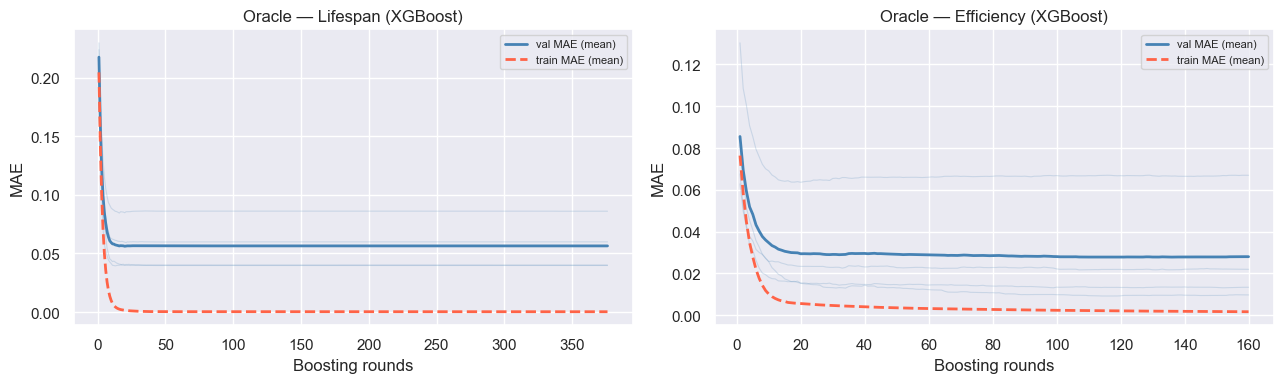

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_gbm_learning_curves(ctrl, oracle_lifespan_feat,   "rul_frac",
                          oracle_life_params["GBM"],
                          "Oracle — Lifespan (XGBoost)", axes[0])
plot_gbm_learning_curves(ctrl, oracle_efficiency_feat, "energy_retention",
                          oracle_eff_params["GBM"],
                          "Oracle — Efficiency (XGBoost)", axes[1])
plt.tight_layout()
plt.savefig(RESULTS / "oracle_learning_curves.png", dpi=150)
plt.show()

### Lifespan

RF and GBM are essentially tied on accuracy — MAE_cyc 5.4 vs 5.3, a difference of one cycle. Not meaningful. The interesting divergence is monotonicity:
- RF: mono=0.801 — 80% of consecutive predictions correctly decrease, RF's bagging smooths predictions cycle-to-cycle
- GBM: mono=0.576 — only barely above 0.5, which is the expected value for a random signal. Despite the best MAE and R², GBM's cycle-by-cycle trajectory is nearly as noisy as noise. It captures the global RUL level well (high R², high ρ) but zigzags locally
- Ridge: mono=0.613 — similarly poor local trend, though its Spearman is slightly lower too

Takeaway: GBM's superiority on MAE is real but its predictions would look erratic plotted over time because of the random monotonicity.

Skill scores (0.69–0.79) are good — the naive baseline (predict training mean) has MAE ~0.296 on this 0–1 target, so all models are cutting that error by 70–80%.

MAE_cyc ~5–8 cycles out of 99–168 → roughly 3–8% of total lifespan. That's reasonable for a practical tool.

### Oracle Efficiency (partial)

Ridge wins here, which is the interesting takeaway. Energy retention is a smooth, approximately linear decline over cycles. With capacity features excluded, the remaining features (voltage, temp, resistance, duration) relate to energy retention fairly directly and linearly — Ridge fits that well.

RF's R²=0.855±0.106 — that std is enormous relative to the mean. It means at least one fold is getting R²~0.75 and another ~0.96. One battery has a degradation trajectory RF can't generalise from or to. The high Spearman (0.989 vs Ridge's 0.984) tells you RF is ranking cycles correctly, but the absolute level is off in bad folds.

The efficiency target is easier overall — Ridge MAE=0.019 vs lifespan MAE=0.092, and R² is higher. The energy retention signal is smoother and lower-variance than RUL.

### Takeaways

We have a consistent pattern across both tasks: Spearman ρ is high (0.935–0.989) even when monotonicity is mediocre. These are measuring different things: ρ captures whether the model correctly orders cycles globally across the full test battery, while monotonicity captures whether it correctly orders consecutive cycle pairs locally. A model can rank all 168 cycles roughly right (high ρ) while still oscillating noisily between adjacent ones (low mono). This indicates that the model is not understanding the temporal aspect of the task. Which makes models like LSTM interesting.*

## 6. Phase 2 — Practical (controlled + randomized merged)

Resistance = `r_proxy` only. `rul_frac` normalises the cycle-count mismatch between controlled (~168 cycles/battery) and randomized (~11–40 reference cycles/battery).

In [28]:
shared_cols = [c for c in ctrl.columns if c in rw.columns]
merged = pd.concat([ctrl[shared_cols], rw[shared_cols]], ignore_index=True)

practical_lifespan_feat   = make_feature_set(merged, exclude_eis=True, exclude_capacity=False)
practical_efficiency_feat = make_feature_set(merged, exclude_eis=True, exclude_capacity=True)

print(f"Merged: {len(merged)} rows, {merged.battery_id.nunique()} batteries")
print(f"Practical lifespan features  : {practical_lifespan_feat}")
print(f"Practical efficiency features: {practical_efficiency_feat}")

Merged: 801 rows, 13 batteries
Practical lifespan features  : ['capacity_ahr', 'capacity_retention', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s', 'r_proxy', 'cap_delta_from_baseline']
Practical efficiency features: ['voltage_mean', 'temp_mean', 'temp_max', 'duration_s', 'r_proxy']


### 6a. Practical — baseline hyperparameters

Optuna is omitted here: with 13 LOBO folds, 3 algorithms, and 2 tasks, 400 × 13 × 4 = 20 800+ XGBoost fits make tuning prohibitively slow. Instead we set principled baselines informed by the data size (~740 training rows per fold, ~12–15 features) and tune manually from the learning curves.

#### Reasoning

| Param | Value | Why |
|---|---|---|
| **Ridge** `alpha` | `1.0` | ~740 rows vs ~15 features → low regularisation pressure needed; 1.0 is a neutral default. Decrease toward 0.01 if R² is lower than expected; increase toward 100 if folds are unstable. |
| **RF** `n_estimators` | `300` | Enough for stable OOB variance reduction on this size; more trees never overfit (bagging), just slower. |
| **RF** `max_depth` | `8` | Unconstrained depth memorises small training sets. Depth 8 (256 max leaves) is conservative for ~740 rows. |
| **RF** `min_samples_leaf` | `3` | Prevents micro-leaves; with 740 rows this still allows fine-grained splits. |
| **RF** `max_features` | `0.6` | Above the `sqrt` default (~0.33) to give broader feature coverage per split on a small feature set. |
| **XGB** `n_estimators` | `300` | Starting point; adjust based on learning curves — val still descending at 300 → increase; plateau well before 300 → decrease. |
| **XGB** `learning_rate` | `0.05` | Slow learner + many trees is the classic XGB recipe for robustness. Produces smoother per-cycle predictions → better monotonicity. |
| **XGB** `max_depth` | `4` | XGBoost greedy splits overfit easily on small data; depth 4 (16 max leaves) is conservative. |
| **XGB** `subsample` | `0.8` | Row subsampling reduces variance. |
| **XGB** `colsample_bytree` | `0.7` | Column subsampling prevents individual features dominating across all trees. |
| **XGB** `min_child_weight` | `5` | Requires ≥5 samples per leaf — with 740 training rows this meaningfully prevents over-splitting. |
| **XGB** `reg_alpha` | `0.1` | Light L1; keeps the model sparse without forcing many zero weights. |
| **XGB** `reg_lambda` | `1.0` | XGBoost's own default; moderate L2. |

#### Manual tuning tips

**Learning curves (most important):**
- Val MAE still descending at the last round → increase `n_estimators` (try ×2)
- Train–val gap opens wide in the first ~50 rounds → reduce `max_depth` to 3, or raise `min_child_weight` to 10; the model is fitting noise early
- Val curve is noisy / large spread between folds → reduce `learning_rate` to 0.02 and increase `n_estimators` proportionally; or raise `subsample` to 1.0
- Train and val converge but at a high MAE → underfitting; try `max_depth=6`, `min_child_weight=1`, `colsample_bytree=1.0`

**Other metrics:**
- Low **monotonicity** despite good MAE → lower `learning_rate` (produces smoother trajectories); or for RF, increase `min_samples_leaf`
- High **R² std** (unstable across folds) → one outlier battery; note which fold drives the variance in the learning curves and investigate whether that battery has an unusual degradation trajectory
- Good **ρ** but poor **R²** → model ranks batteries correctly but absolute level is off; Ridge: try smaller `alpha`; trees: increase `n_estimators`

In [29]:
PRACTICAL_PARAMS = {
    "Ridge": {"alpha": 1.0},
    "RF": {
        "n_estimators":     300,
        "max_depth":        8,
        "min_samples_leaf": 3,
        "max_features":     0.6,
        "random_state":     42,
    },
    "GBM": {
        "n_estimators":     300,
        "learning_rate":    0.05,
        "max_depth":        4,
        "subsample":        0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 5,
        "reg_alpha":        0.1,
        "reg_lambda":       1.0,
        "random_state":     42,
        "verbosity":        0,
    },
}

practical_life_params = PRACTICAL_PARAMS
practical_eff_params  = PRACTICAL_PARAMS
print("Practical baseline params set.")

Practical baseline params set.


### 6b. Practical — evaluate with tuned models

In [30]:
practical_life_factories = {a: make_factory(a, p) for a, p in practical_life_params.items()}
practical_eff_factories  = {a: make_factory(a, p) for a, p in practical_eff_params.items()}

print(f"Practical lifespan — {merged.battery_id.nunique()} LOBO folds")
practical_life_results = run_phase(merged, practical_lifespan_feat, "rul_frac",
                                   "Practical", "Lifespan",
                                   practical_life_factories, eol_col="eol_index")

print(f"\nPractical efficiency — {merged.battery_id.nunique()} LOBO folds")
practical_eff_results = run_phase(merged, practical_efficiency_feat, "energy_retention",
                                  "Practical", "Efficiency",
                                  practical_eff_factories)

Practical lifespan — 13 LOBO folds
  Ridge    MAE=0.1358±0.0779  R²=0.560±0.779  ρ=0.857  mono=0.739  skill=0.537  MAE_cyc=3.1
  RF       MAE=0.0317±0.0192  R²=0.966±0.033  ρ=0.920  mono=0.926  skill=0.892  MAE_cyc=1.5
  GBM      MAE=0.0349±0.0225  R²=0.961±0.038  ρ=0.874  mono=0.737  skill=0.881  MAE_cyc=1.8

Practical efficiency — 13 LOBO folds
  Ridge    MAE=0.0574±0.0295  R²=0.757±0.209  ρ=0.945  mono=0.846  skill=0.632
  RF       MAE=0.0323±0.0348  R²=0.848±0.243  ρ=0.987  mono=0.855  skill=0.758
  GBM      MAE=0.0373±0.0366  R²=0.811±0.293  ρ=0.974  mono=0.813  skill=0.724


### 6c. Practical — GBM learning curves

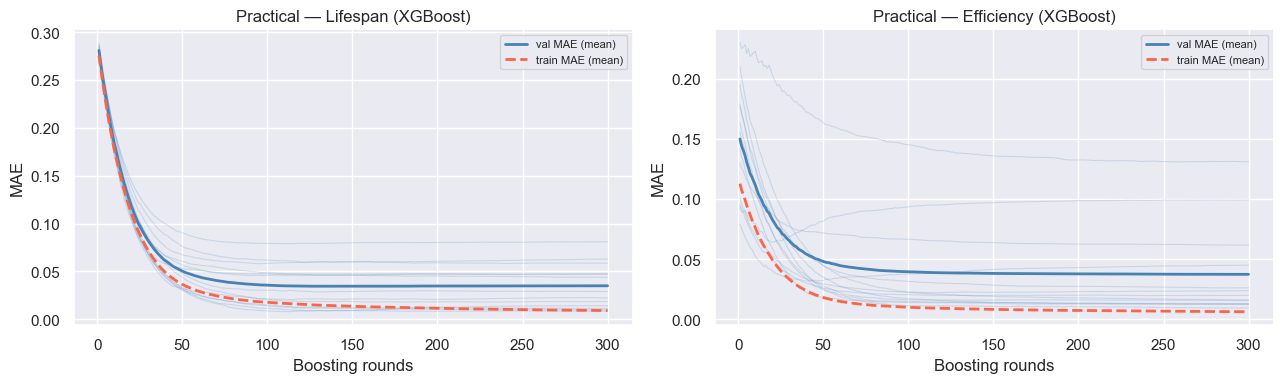

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_gbm_learning_curves(merged, practical_lifespan_feat,   "rul_frac",
                          PRACTICAL_PARAMS["GBM"],
                          "Practical — Lifespan (XGBoost)", axes[0])
plot_gbm_learning_curves(merged, practical_efficiency_feat, "energy_retention",
                          PRACTICAL_PARAMS["GBM"],
                          "Practical — Efficiency (XGBoost)", axes[1])
plt.tight_layout()
plt.savefig(RESULTS / "practical_learning_curves.png", dpi=150)
plt.show()

## 7. Results & comparison

### 7a. Master metrics table

In [32]:
all_results = pd.concat(
    [oracle_life_results, oracle_eff_results,
     practical_life_results, practical_eff_results],
    ignore_index=True
)

def fmt(val, std=None, decimals=4):
    if pd.isna(val): return "—"
    s = f"{val:.{decimals}f}"
    if std is not None and not pd.isna(std):
        s += f" ± {std:.{decimals}f}"
    return s

rows = []
for _, r in all_results.iterrows():
    d = {
        "Phase":       r["Phase"],
        "Task":        r["Task"],
        "Algorithm":   r["Algorithm"],
        "MAE ± std":   fmt(r.get("mae"), r.get("mae_std")),
        "RMSE ± std":  fmt(r.get("rmse"), r.get("rmse_std")),
        "R² ± std":    fmt(r.get("r2"), r.get("r2_std"), decimals=3),
        "Naive MAE":   fmt(r.get("naive_mae"), decimals=4),
        "Skill score": fmt(r.get("skill"), decimals=3),
        "Spearman ρ":  fmt(r.get("spearman"), decimals=3),
        "Monotonicity": fmt(r.get("monotonicity"), decimals=3),
    }
    if "mae_cycles" in r and not pd.isna(r.get("mae_cycles", float("nan"))):
        d["MAE (cycles) ± std"] = fmt(r.get("mae_cycles"), r.get("mae_cycles_std"), decimals=1)
    rows.append(d)

table = pd.DataFrame(rows).set_index(["Phase", "Task", "Algorithm"])
display(table)

MAE ± std       RMSE ± std  \
Phase     Task       Algorithm                                     
Oracle    Lifespan   Ridge      0.1057 ± 0.0335  0.1302 ± 0.0418   
                     RF         0.0614 ± 0.0129  0.0933 ± 0.0268   
                     GBM        0.0565 ± 0.0189  0.0855 ± 0.0275   
          Efficiency Ridge      0.0196 ± 0.0055  0.0253 ± 0.0076   
                     RF         0.0324 ± 0.0200  0.0378 ± 0.0217   
                     GBM        0.0280 ± 0.0229  0.0333 ± 0.0239   
Practical Lifespan   Ridge      0.1358 ± 0.0779  0.1710 ± 0.0845   
                     RF         0.0317 ± 0.0192  0.0537 ± 0.0281   
                     GBM        0.0349 ± 0.0225  0.0556 ± 0.0325   
          Efficiency Ridge      0.0574 ± 0.0295  0.0686 ± 0.0292   
                     RF         0.0323 ± 0.0348  0.0373 ± 0.0377   
                     GBM        0.0373 ± 0.0366  0.0442 ± 0.0415   

                                     R² ± std Naive MAE Skill score  \
Phase     Task       Algorithm                                        
Oracle    Lifespan   Ridge      0.816 ± 0.110    0.2975       0.646   
                     RF         0.908 ± 0.049    0.2975       0.794   
                     GBM        0.925 ± 0.048    0.2975       0.809   
          Efficiency Ridge      0.932 ± 0.053    0.1036       0.801   
                     RF         0.859 ± 0.108    0.1036       0.705   
                     GBM        0.884 ± 0.111    0.1036       0.755   
Practical Lifespan   Ridge      0.560 ± 0.779    0.2950       0.537   
                     RF         0.966 ± 0.033    0.2950       0.892   
                     GBM        0.961 ± 0.038    0.2950       0.881   
          Efficiency Ridge      0.757 ± 0.209    0.1562       0.632   
                     RF         0.848 ± 0.243    0.1562       0.758   
                     GBM        0.811 ± 0.293    0.1562       0.724   

                               Spearman ρ Monotonicity MAE (cycles) ± std  
Phase     Task       Algorithm                                             
Oracle    Lifespan   Ridge          0.939        0.730          8.7 ± 1.0  
                     RF             0.940        0.850          5.2 ± 0.7  
                     GBM            0.936        0.597          5.1 ± 2.0  
          Efficiency Ridge          0.986        0.737                NaN  
                     RF             0.991        0.700                NaN  
                     GBM            0.989        0.617                NaN  
Practical Lifespan   Ridge          0.857        0.739          3.1 ± 3.3  
                     RF             0.920        0.926          1.5 ± 2.3  
                     GBM            0.874        0.737          1.8 ± 2.6  
          Efficiency Ridge          0.945        0.846                NaN  
                     RF             0.987        0.855                NaN  
                     GBM            0.974        0.813                NaN

### 7c. Predicted vs actual scatter (best model per phase/task)

Best oracle lifespan: GBM  |  oracle eff: Ridge
Best practical lifespan: RF  |  practical eff: RF


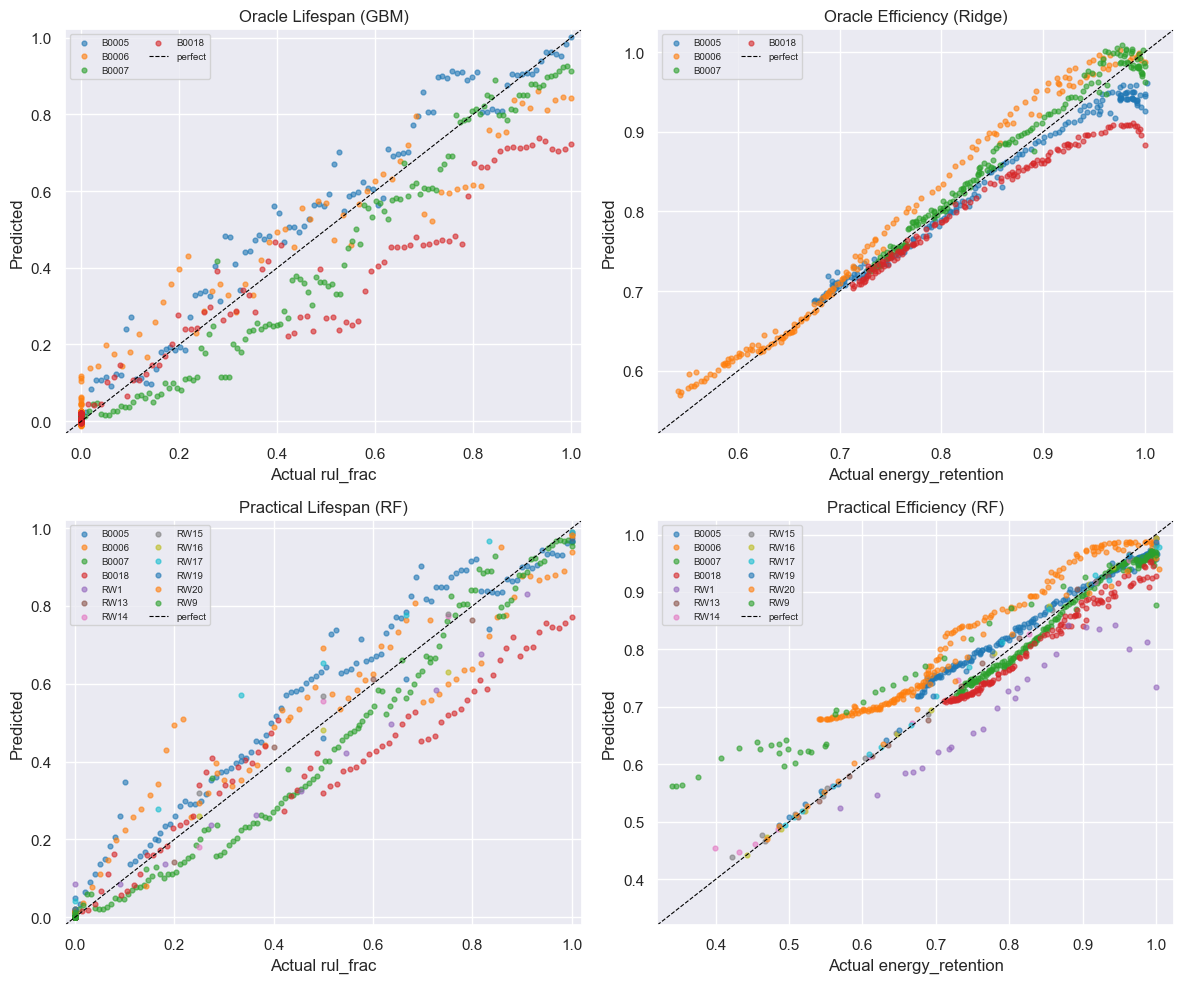

In [33]:
def best_algo(results_df):
    return results_df.loc[results_df["r2"].idxmax(), "Algorithm"]


def collect_oof(df, feature_cols, target, factory):
    X, y, groups = df[feature_cols].to_numpy(), df[target].to_numpy(), df["battery_id"].to_numpy()
    y_pred = np.full_like(y, np.nan)
    for train_idx, test_idx in LeaveOneGroupOut().split(X, y, groups):
        m = factory()
        m.fit(X[train_idx], y[train_idx])
        y_pred[test_idx] = m.predict(X[test_idx])
    return pd.DataFrame({"battery_id": df["battery_id"].values,
                          "cycle_index": df["cycle_index"].values,
                          "y_true": y, "y_pred": y_pred})


ALGO_FACTORIES = {
    "oracle_life":  {a: make_factory(a, p) for a, p in oracle_life_params.items()},
    "oracle_eff":   {a: make_factory(a, p) for a, p in oracle_eff_params.items()},
    "pract_life":   {a: make_factory(a, p) for a, p in practical_life_params.items()},
    "pract_eff":    {a: make_factory(a, p) for a, p in practical_eff_params.items()},
}

b_ol = best_algo(oracle_life_results)
b_oe = best_algo(oracle_eff_results)
b_pl = best_algo(practical_life_results)
b_pe = best_algo(practical_eff_results)
print(f"Best oracle lifespan: {b_ol}  |  oracle eff: {b_oe}")
print(f"Best practical lifespan: {b_pl}  |  practical eff: {b_pe}")

oof_ol = collect_oof(ctrl,   oracle_lifespan_feat,     "rul_frac",         ALGO_FACTORIES["oracle_life"][b_ol])
oof_oe = collect_oof(ctrl,   oracle_efficiency_feat,   "energy_retention", ALGO_FACTORIES["oracle_eff"][b_oe])
oof_pl = collect_oof(merged, practical_lifespan_feat,  "rul_frac",         ALGO_FACTORIES["pract_life"][b_pl])
oof_pe = collect_oof(merged, practical_efficiency_feat,"energy_retention", ALGO_FACTORIES["pract_eff"][b_pe])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, oof, title, xlabel in [
    (axes[0,0], oof_ol, f"Oracle Lifespan ({b_ol})",    "Actual rul_frac"),
    (axes[0,1], oof_oe, f"Oracle Efficiency ({b_oe})",  "Actual energy_retention"),
    (axes[1,0], oof_pl, f"Practical Lifespan ({b_pl})", "Actual rul_frac"),
    (axes[1,1], oof_pe, f"Practical Efficiency ({b_pe})","Actual energy_retention"),
]:
    for bid, grp in oof.groupby("battery_id"):
        ax.scatter(grp["y_true"], grp["y_pred"], s=12, alpha=0.6, label=bid)
    lims = [min(oof["y_true"].min(), oof["y_pred"].min()) - 0.02,
            max(oof["y_true"].max(), oof["y_pred"].max()) + 0.02]
    ax.plot(lims, lims, "k--", lw=0.8, label="perfect")
    ax.set(xlim=lims, ylim=lims, xlabel=xlabel, ylabel="Predicted", title=title)
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "predicted_vs_actual.png", dpi=150)
plt.show()

### 7d. RUL trajectory — held-out battery walkthrough

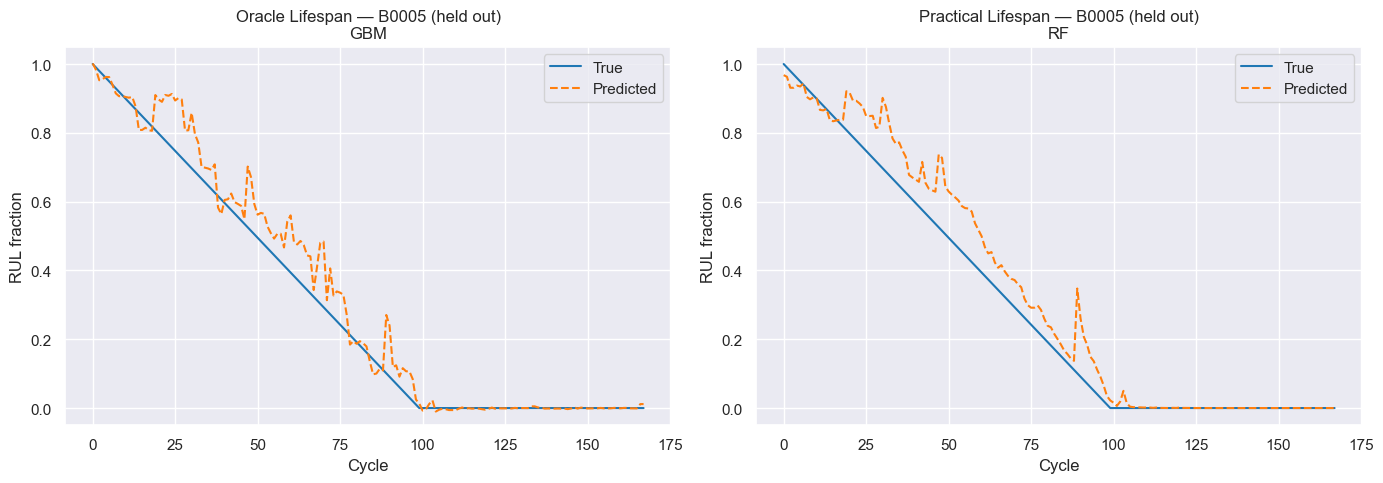

In [34]:
oracle_show = ctrl.groupby("battery_id")["cycle_index"].max().idxmax()
pract_show  = merged.groupby("battery_id")["cycle_index"].max().idxmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, oof, show, title in [
    (axes[0], oof_ol, oracle_show, f"Oracle Lifespan — {oracle_show} (held out)\n{b_ol}"),
    (axes[1], oof_pl, pract_show,  f"Practical Lifespan — {pract_show} (held out)\n{b_pl}"),
]:
    grp = oof[oof["battery_id"] == show].sort_values("cycle_index")
    ax.plot(grp["cycle_index"], grp["y_true"], label="True",      lw=1.5)
    ax.plot(grp["cycle_index"], grp["y_pred"], label="Predicted", lw=1.5, ls="--")
    ax.set(xlabel="Cycle", ylabel="RUL fraction", title=title, ylim=(-0.05, 1.05))
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "rul_trajectory.png", dpi=150)
plt.show()

Both models generalize well to the unseen test, which is great news. They do oscillate a lot locally though - they would benefit from a temporal point of view.

### 7e. Feature importance (RF, tuned)

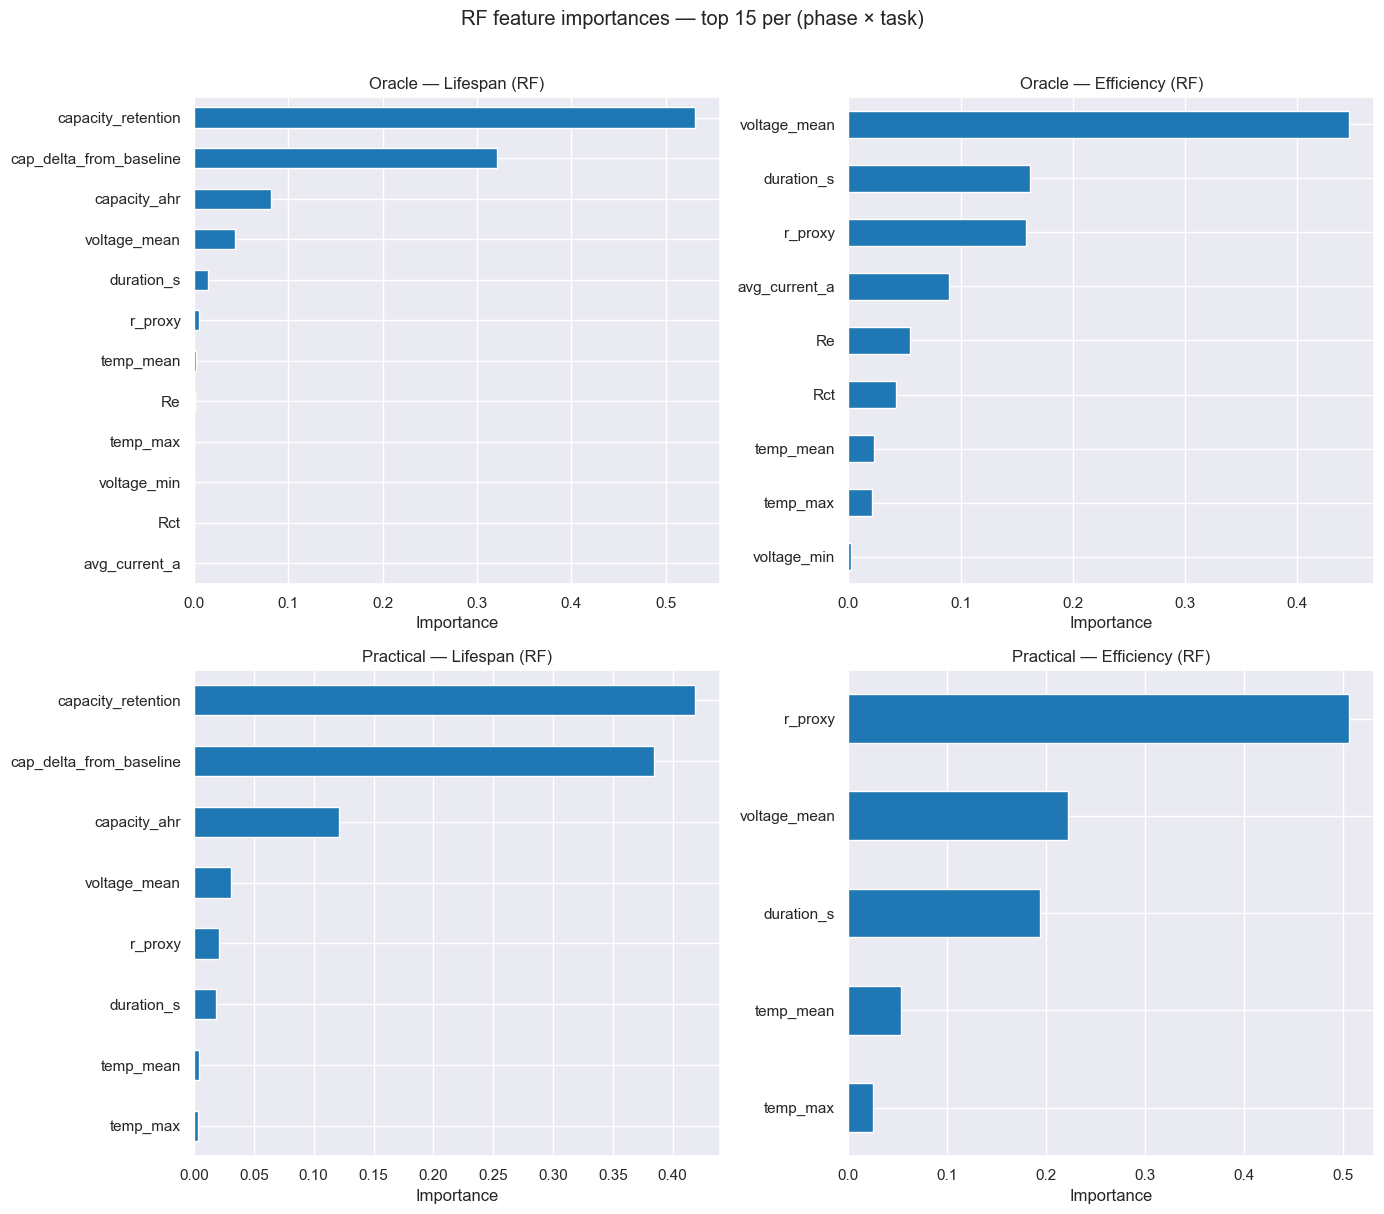

In [35]:
def rf_importance(df, feat, target, params, top_n=15):
    m = RandomForestRegressor(**{**params, "random_state": 42})
    m.fit(df[feat], df[target])
    return pd.Series(m.feature_importances_, index=feat).sort_values(ascending=False).head(top_n)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, df_, feat, target, params, title in [
    (axes[0, 0], ctrl,   oracle_lifespan_feat,      "rul_frac",         oracle_life_params["RF"],    "Oracle — Lifespan (RF)"),
    (axes[0, 1], ctrl,   oracle_efficiency_feat,    "energy_retention", oracle_eff_params["RF"],     "Oracle — Efficiency (RF)"),
    (axes[1, 0], merged, practical_lifespan_feat,   "rul_frac",         practical_life_params["RF"], "Practical — Lifespan (RF)"),
    (axes[1, 1], merged, practical_efficiency_feat, "energy_retention", practical_eff_params["RF"],  "Practical — Efficiency (RF)"),
]:
    imp = rf_importance(df_, feat, target, params)
    imp[::-1].plot.barh(ax=ax)
    ax.set(title=title, xlabel="Importance")

plt.suptitle("RF feature importances — top 15 per (phase × task)", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Persist best models

In [36]:
for phase, df_, feat, target, factories, algo in [
    ("oracle",    ctrl,   oracle_lifespan_feat,      "rul_frac",         ALGO_FACTORIES["oracle_life"], b_ol),
    ("oracle",    ctrl,   oracle_efficiency_feat,    "energy_retention", ALGO_FACTORIES["oracle_eff"],  b_oe),
    ("practical", merged, practical_lifespan_feat,   "rul_frac",         ALGO_FACTORIES["pract_life"],  b_pl),
    ("practical", merged, practical_efficiency_feat, "energy_retention", ALGO_FACTORIES["pract_eff"],   b_pe),
]:
    task_slug = "lifespan" if target == "rul_frac" else "efficiency"
    fname = MODELS / f"{phase}_{task_slug}_{algo.lower()}.pkl"
    model = factories[algo]()
    model.fit(df_[feat], df_[target])
    joblib.dump({"model": model, "feature_cols": feat,
                 "phase": phase, "task": task_slug, "algorithm": algo}, fname)
    print(f"Saved: {fname.name}")

Saved: oracle_lifespan_gbm.pkl
Saved: oracle_efficiency_ridge.pkl
Saved: practical_lifespan_rf.pkl
Saved: practical_efficiency_rf.pkl


## 9. Summary

### Metrics guide

- **Skill score > 0** means the model beats a naive "predict the training mean" baseline. A skill of 0.5 means the model's MAE is half the naive error.
- **Spearman ρ** close to 1 means the model correctly ranks batteries by how degraded they are — valuable for fleet-level triage even if absolute predictions are noisy.
- **Monotonicity** close to 1 means the model reliably predicts that each successive cycle is worse than the last, consistent with irreversible battery aging.

### Oracle vs Practical gap
The drop from oracle to practical metrics (§7b) is the cost of deploying in the field: losing EIS and having to rely on the onset DCIR proxy, while simultaneously expanding to cover renewable-proxy random-walk batteries.

### Tiny-data caveat
4 (oracle) / 13 (practical) batteries → fold-to-fold variance is high. Standard deviations are honest and expected. Treat all numbers as order-of-magnitude, not precision benchmarks.

### Next — Phase 3 (Deep Learning)
Notebook 04 will train an LSTM on the same practical feature set with the same LOBO-CV harness. Given the data size, the baselines here are expected to be hard to beat without aggressive regularisation.